In [20]:
import pandas as pd

team_stats = pd.read_csv("nba_team_opponent_combined_2010_2024.csv")
salaries = pd.read_csv("nba_salary_cap_2010_2024.csv").rename(columns={'SEASON_START':'SEASON', 'TEAM_NAME': 'Team'})
injuries = pd.read_csv("nba_team_injuries_2010_2024.csv").rename(columns={'TEAM': 'TEAM_ABBREVIATION', 'RANK': 'INJURY_RANK'})

merged = pd.merge(
    team_stats,
    salaries,
    how="left",
    on=["Team", "SEASON"]
)
merged['DEAD_CAP'] = merged['DEAD_CAP'].fillna(0) # for teams with no dead cap

merged["WINS"] = pd.to_numeric(merged["RECORD"].str.split("-").str[0])

merged.to_csv("final.csv")
print(merged.head())


    Rk                   Team   G     MP    FG   FGA    FG%    3P   3PA  \
0  1.0       Sacramento Kings  82  241.8  43.6  88.2  0.494  13.8  37.3   
1  2.0  Golden State Warriors  82  241.8  43.1  90.2  0.479  16.6  43.2   
2  3.0          Atlanta Hawks  82  242.1  44.6  92.4  0.483  10.8  30.5   
3  4.0         Boston Celtics  82  243.7  42.2  88.8  0.475  16.0  42.6   
4  5.0  Oklahoma City Thunder  82  242.1  43.1  92.6  0.465  12.1  34.1   

     3P%  ...  RECORD  PLAYERS_ACTIVE  AVG_AGE_TEAM  TOTAL_CAP_ALLOCATIONS  \
0  0.369  ...   30-52            15.0          25.7            154815256.0   
1  0.385  ...   53-29            15.0          26.7            199320856.0   
2  0.352  ...   43-39            15.0          24.1            149133740.0   
3  0.377  ...   51-31            15.0          27.2            176795764.0   
4  0.356  ...   24-58            15.0          22.6            155437627.0   

   CAP_SPACE_ALL       ACTIVE  ACTIVE_TOP_3    DEAD_CAP       TEAM_ID  WINS  
0 

In [ ]:
# merged = merged.merge(injuries, on=['SEASON', 'TEAM_ABBREVIATION'])

In [3]:
merged.columns

Index(['Rk', 'Team', 'G', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P',
       '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL',
       'BLK', 'TOV', 'PF', 'PTS', 'SEASON', 'Rk_OPP', 'G_OPP', 'MP_OPP',
       'FG_OPP', 'FGA_OPP', 'FG%_OPP', '3P_OPP', '3PA_OPP', '3P%_OPP',
       '2P_OPP', '2PA_OPP', '2P%_OPP', 'FT_OPP', 'FTA_OPP', 'FT%_OPP',
       'ORB_OPP', 'DRB_OPP', 'TRB_OPP', 'AST_OPP', 'STL_OPP', 'BLK_OPP',
       'TOV_OPP', 'PF_OPP', 'PTS_OPP', 'RANK', 'TEAM_ABBREVIATION', 'RECORD',
       'PLAYERS_ACTIVE', 'AVG_AGE_TEAM', 'TOTAL_CAP_ALLOCATIONS',
       'CAP_SPACE_ALL', 'ACTIVE', 'ACTIVE_TOP_3', 'DEAD_CAP', 'TEAM_ID',
       'WINS'],
      dtype='object')

In [21]:
merged = merged.sort_values(['Team', 'SEASON'])
merged['TOP_3_RATIO'] = merged['ACTIVE_TOP_3']/merged['TOTAL_CAP_ALLOCATIONS']
merged['CAP_SPACE_RATIO'] = merged['CAP_SPACE_ALL']/merged['TOTAL_CAP_ALLOCATIONS']
merged['DEAD_CAP_RATIO'] = merged['DEAD_CAP']/merged['TOTAL_CAP_ALLOCATIONS']
merged['PTS_DIFF'] = merged['PTS'] - merged['PTS_OPP']
merged['DREB_DIFF'] = merged['DRB'] - merged['DRB_OPP']
merged['TOV_DIFF'] = merged['TOV'] - merged['TOV_OPP']
merged['FT%_DIFF'] = merged['FT%'] - merged['FT%_OPP']
merged['PREV_WINS'] = merged.groupby('Team')['WINS'].shift(1)

# injury_metrics = ['WINS', 'INJURY_RANK', 'PLAYERS_SEASON_CUMULATIVE', 'CASH_SEASON_CUMULATIVE', 'HEALTH_SCORE']
salary_metrics = ['WINS', 'TOP_3_RATIO', 'CAP_SPACE_RATIO', 'DEAD_CAP_RATIO', 'AVG_AGE_TEAM']
shooting_metrics = ['WINS', 'FG%', '3P', '3PA', '3P%', 'FT', 'FTA', 'FT%_DIFF', 'PTS_DIFF', 'PREV_WINS']
shooting_metrics_opp = ['WINS', 'FG_OPP', 'FGA_OPP', 'FG%_OPP', '3P_OPP', '3P%_OPP','2P_OPP', 'PTS_OPP']
other_metrics =  ['WINS', 'ORB', 'DRB', 'TRB', 'BLK', 'TOV', 'TOV_DIFF', 'DREB_DIFF' ]
other_metrics_opp = ['WINS',  'ORB_OPP', 'DRB_OPP', 'TRB_OPP', 'AST_OPP', 'STL_OPP', 'BLK_OPP', 'TOV_OPP', 'PF_OPP',]

In [37]:
# import seaborn as sns 

# sns.pairplot(merged[injury_metrics])

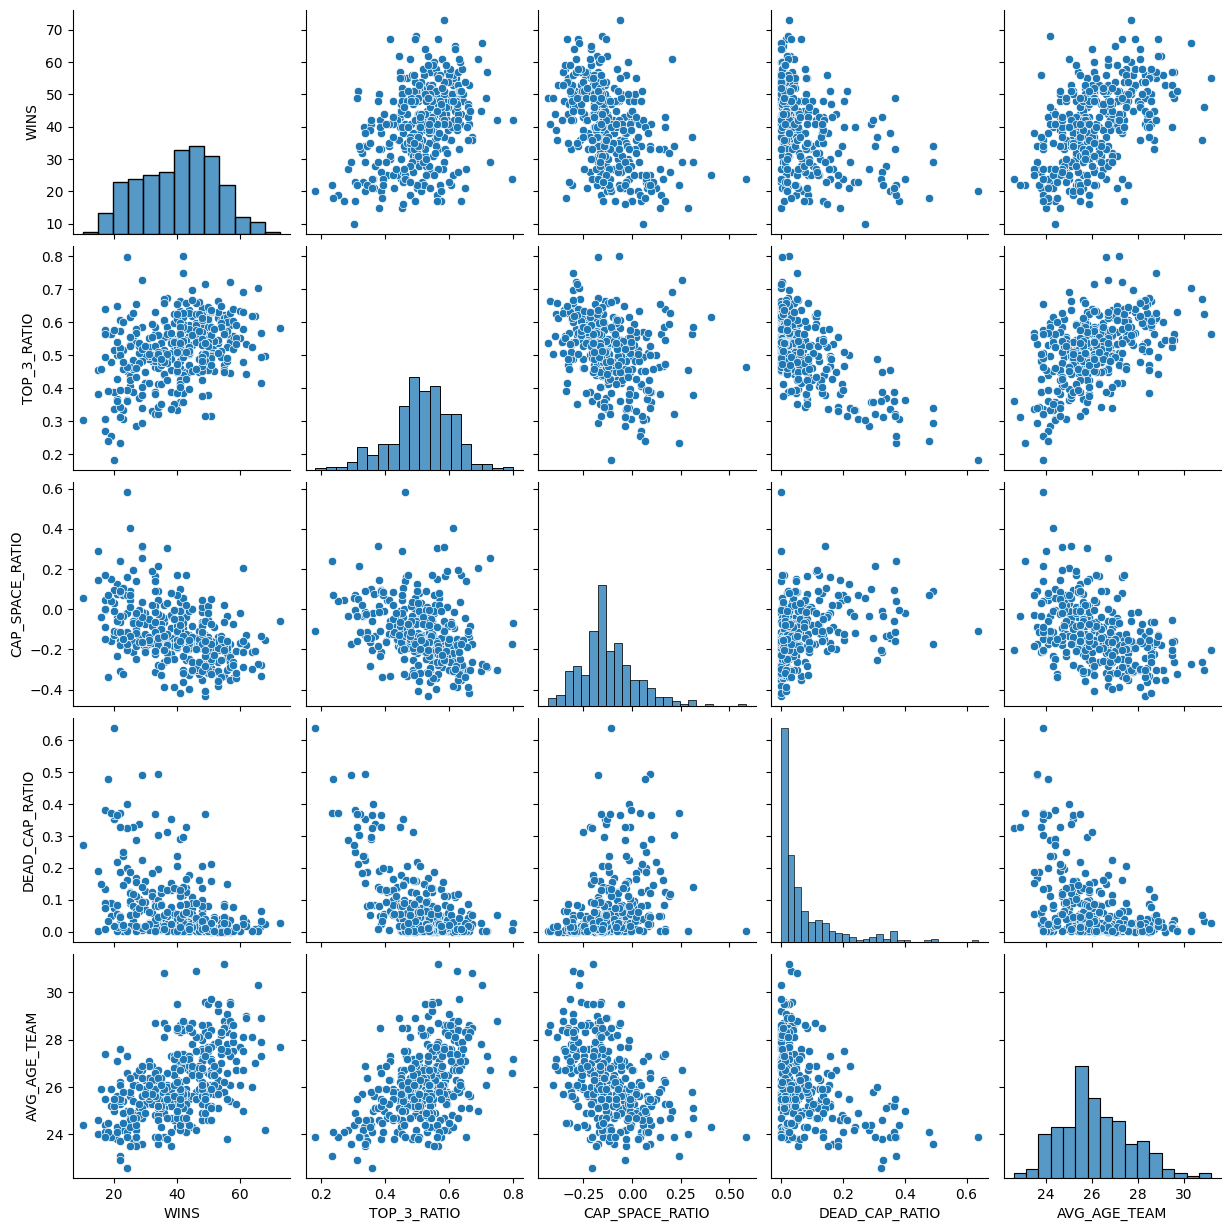

In [8]:
import seaborn as sns 

sns.pairplot(merged[salary_metrics])

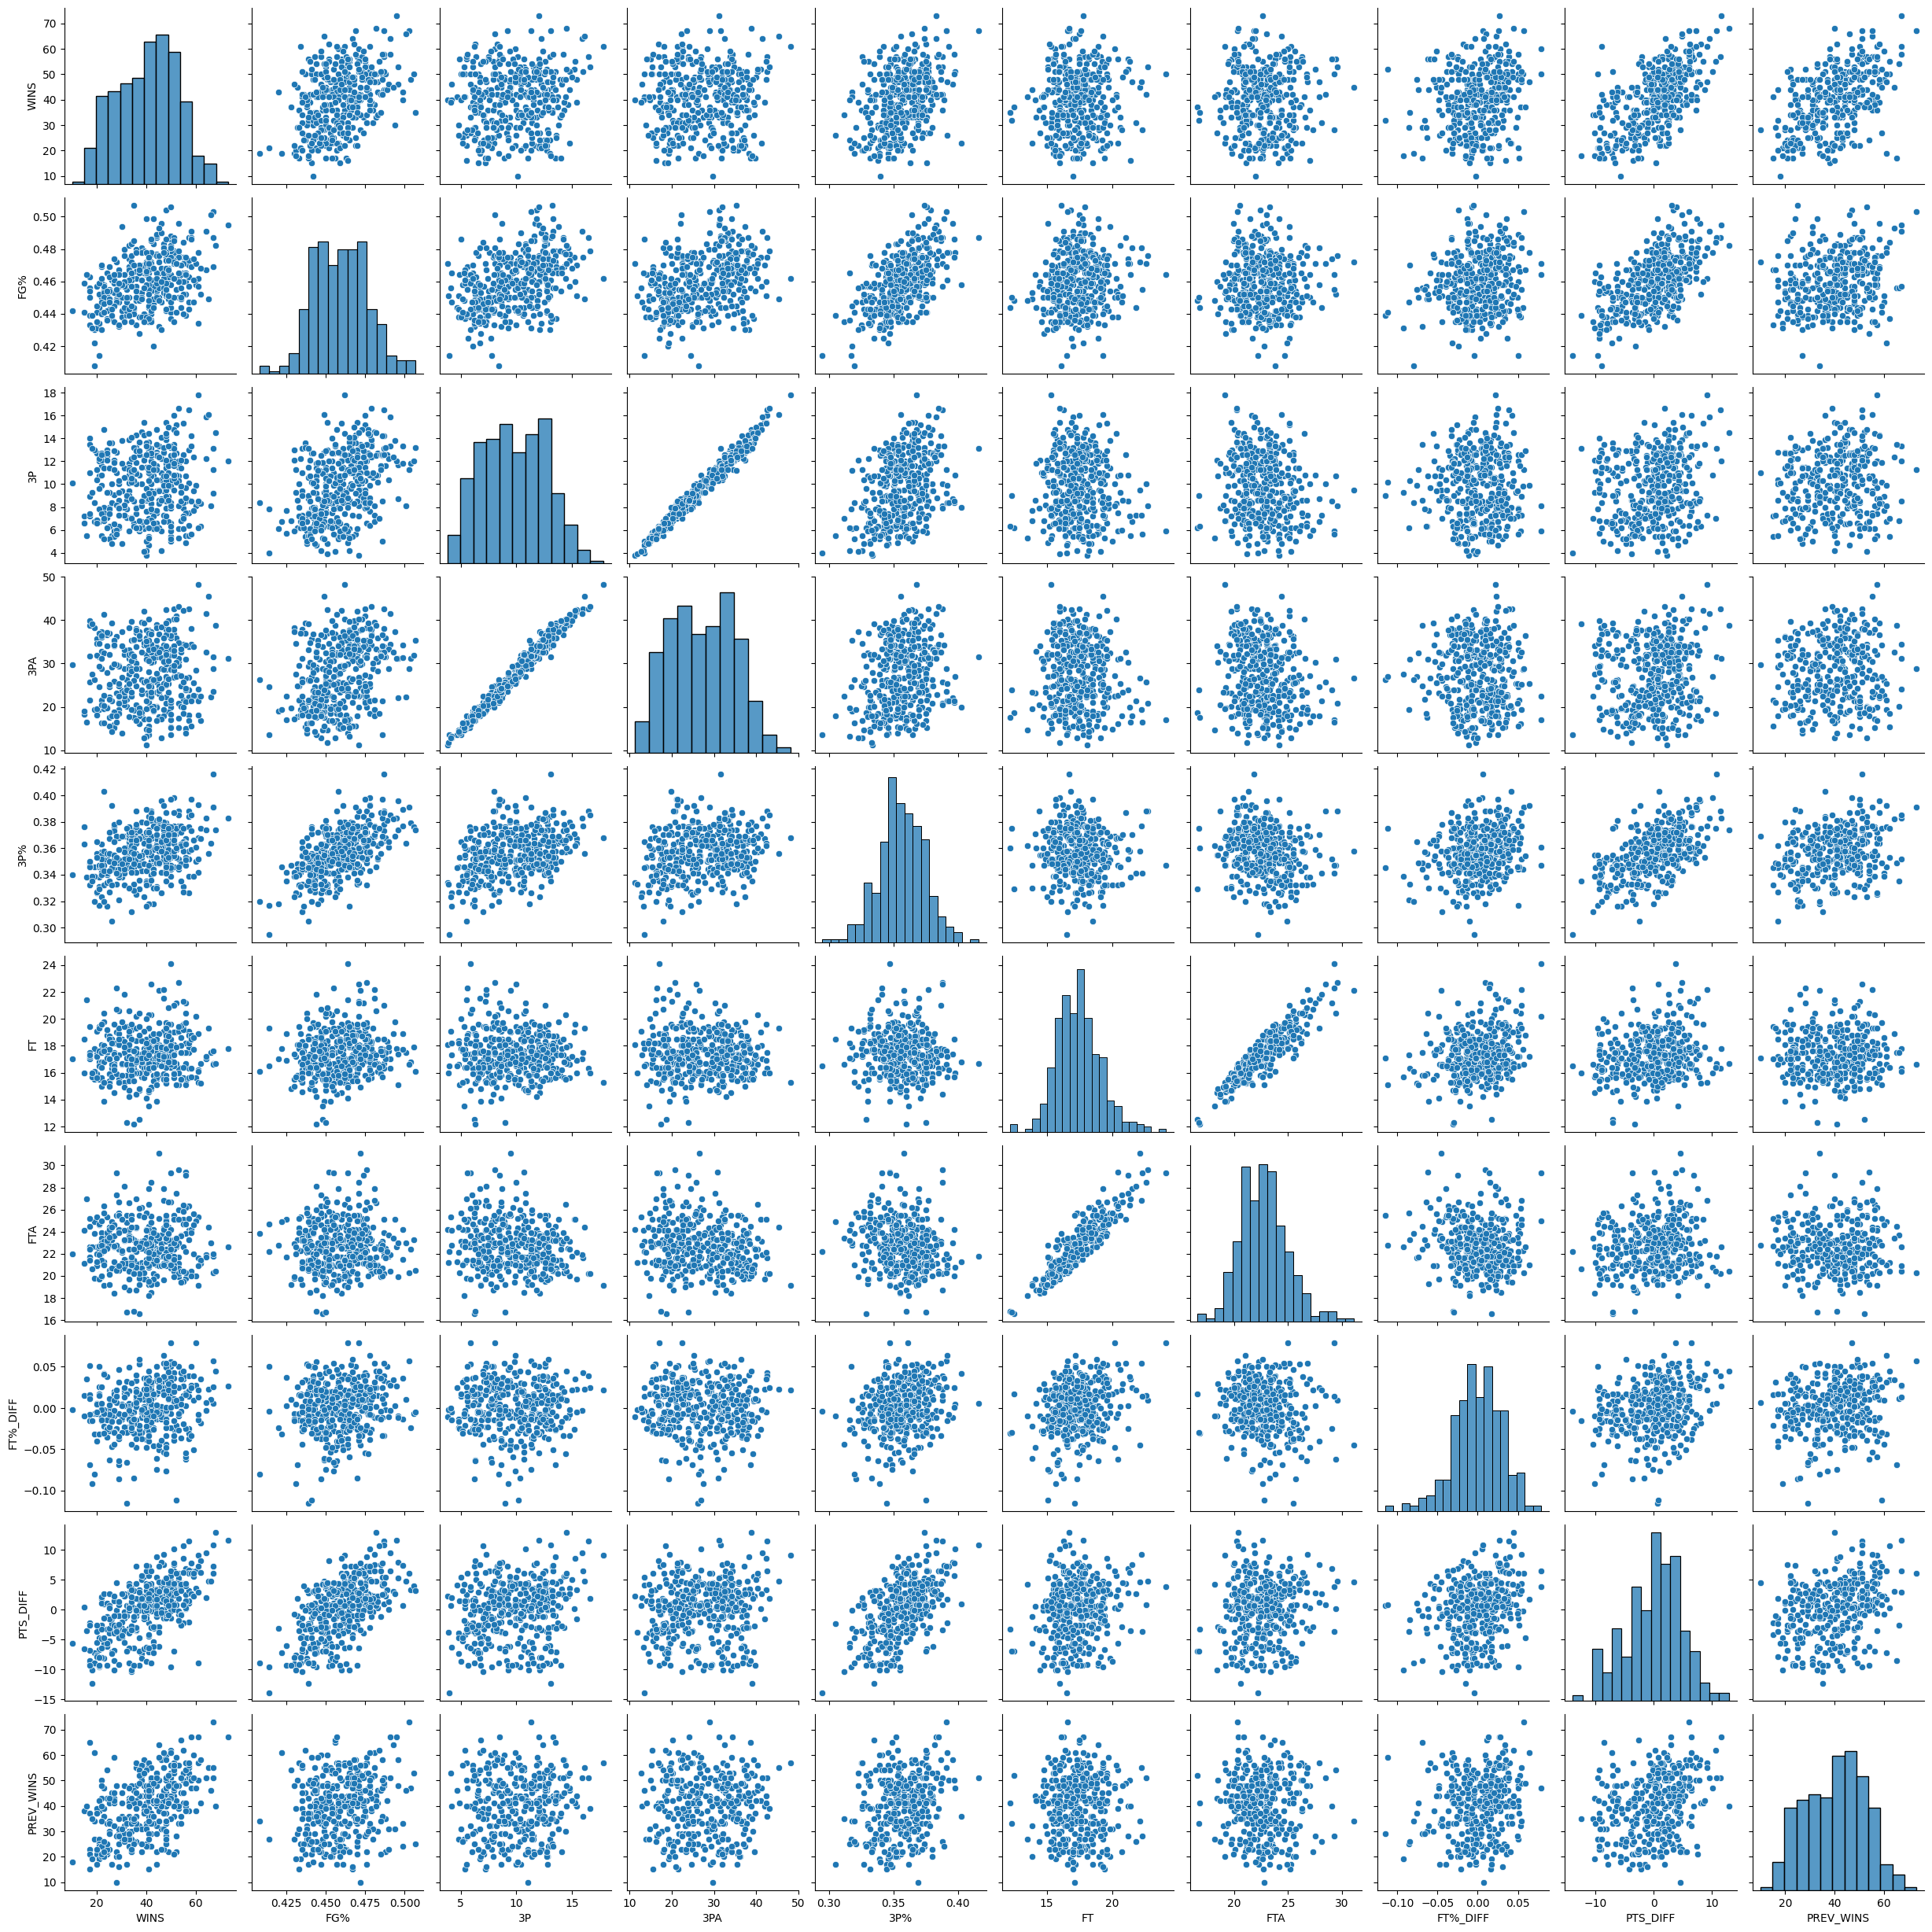

In [17]:
sns.pairplot(merged[shooting_metrics])

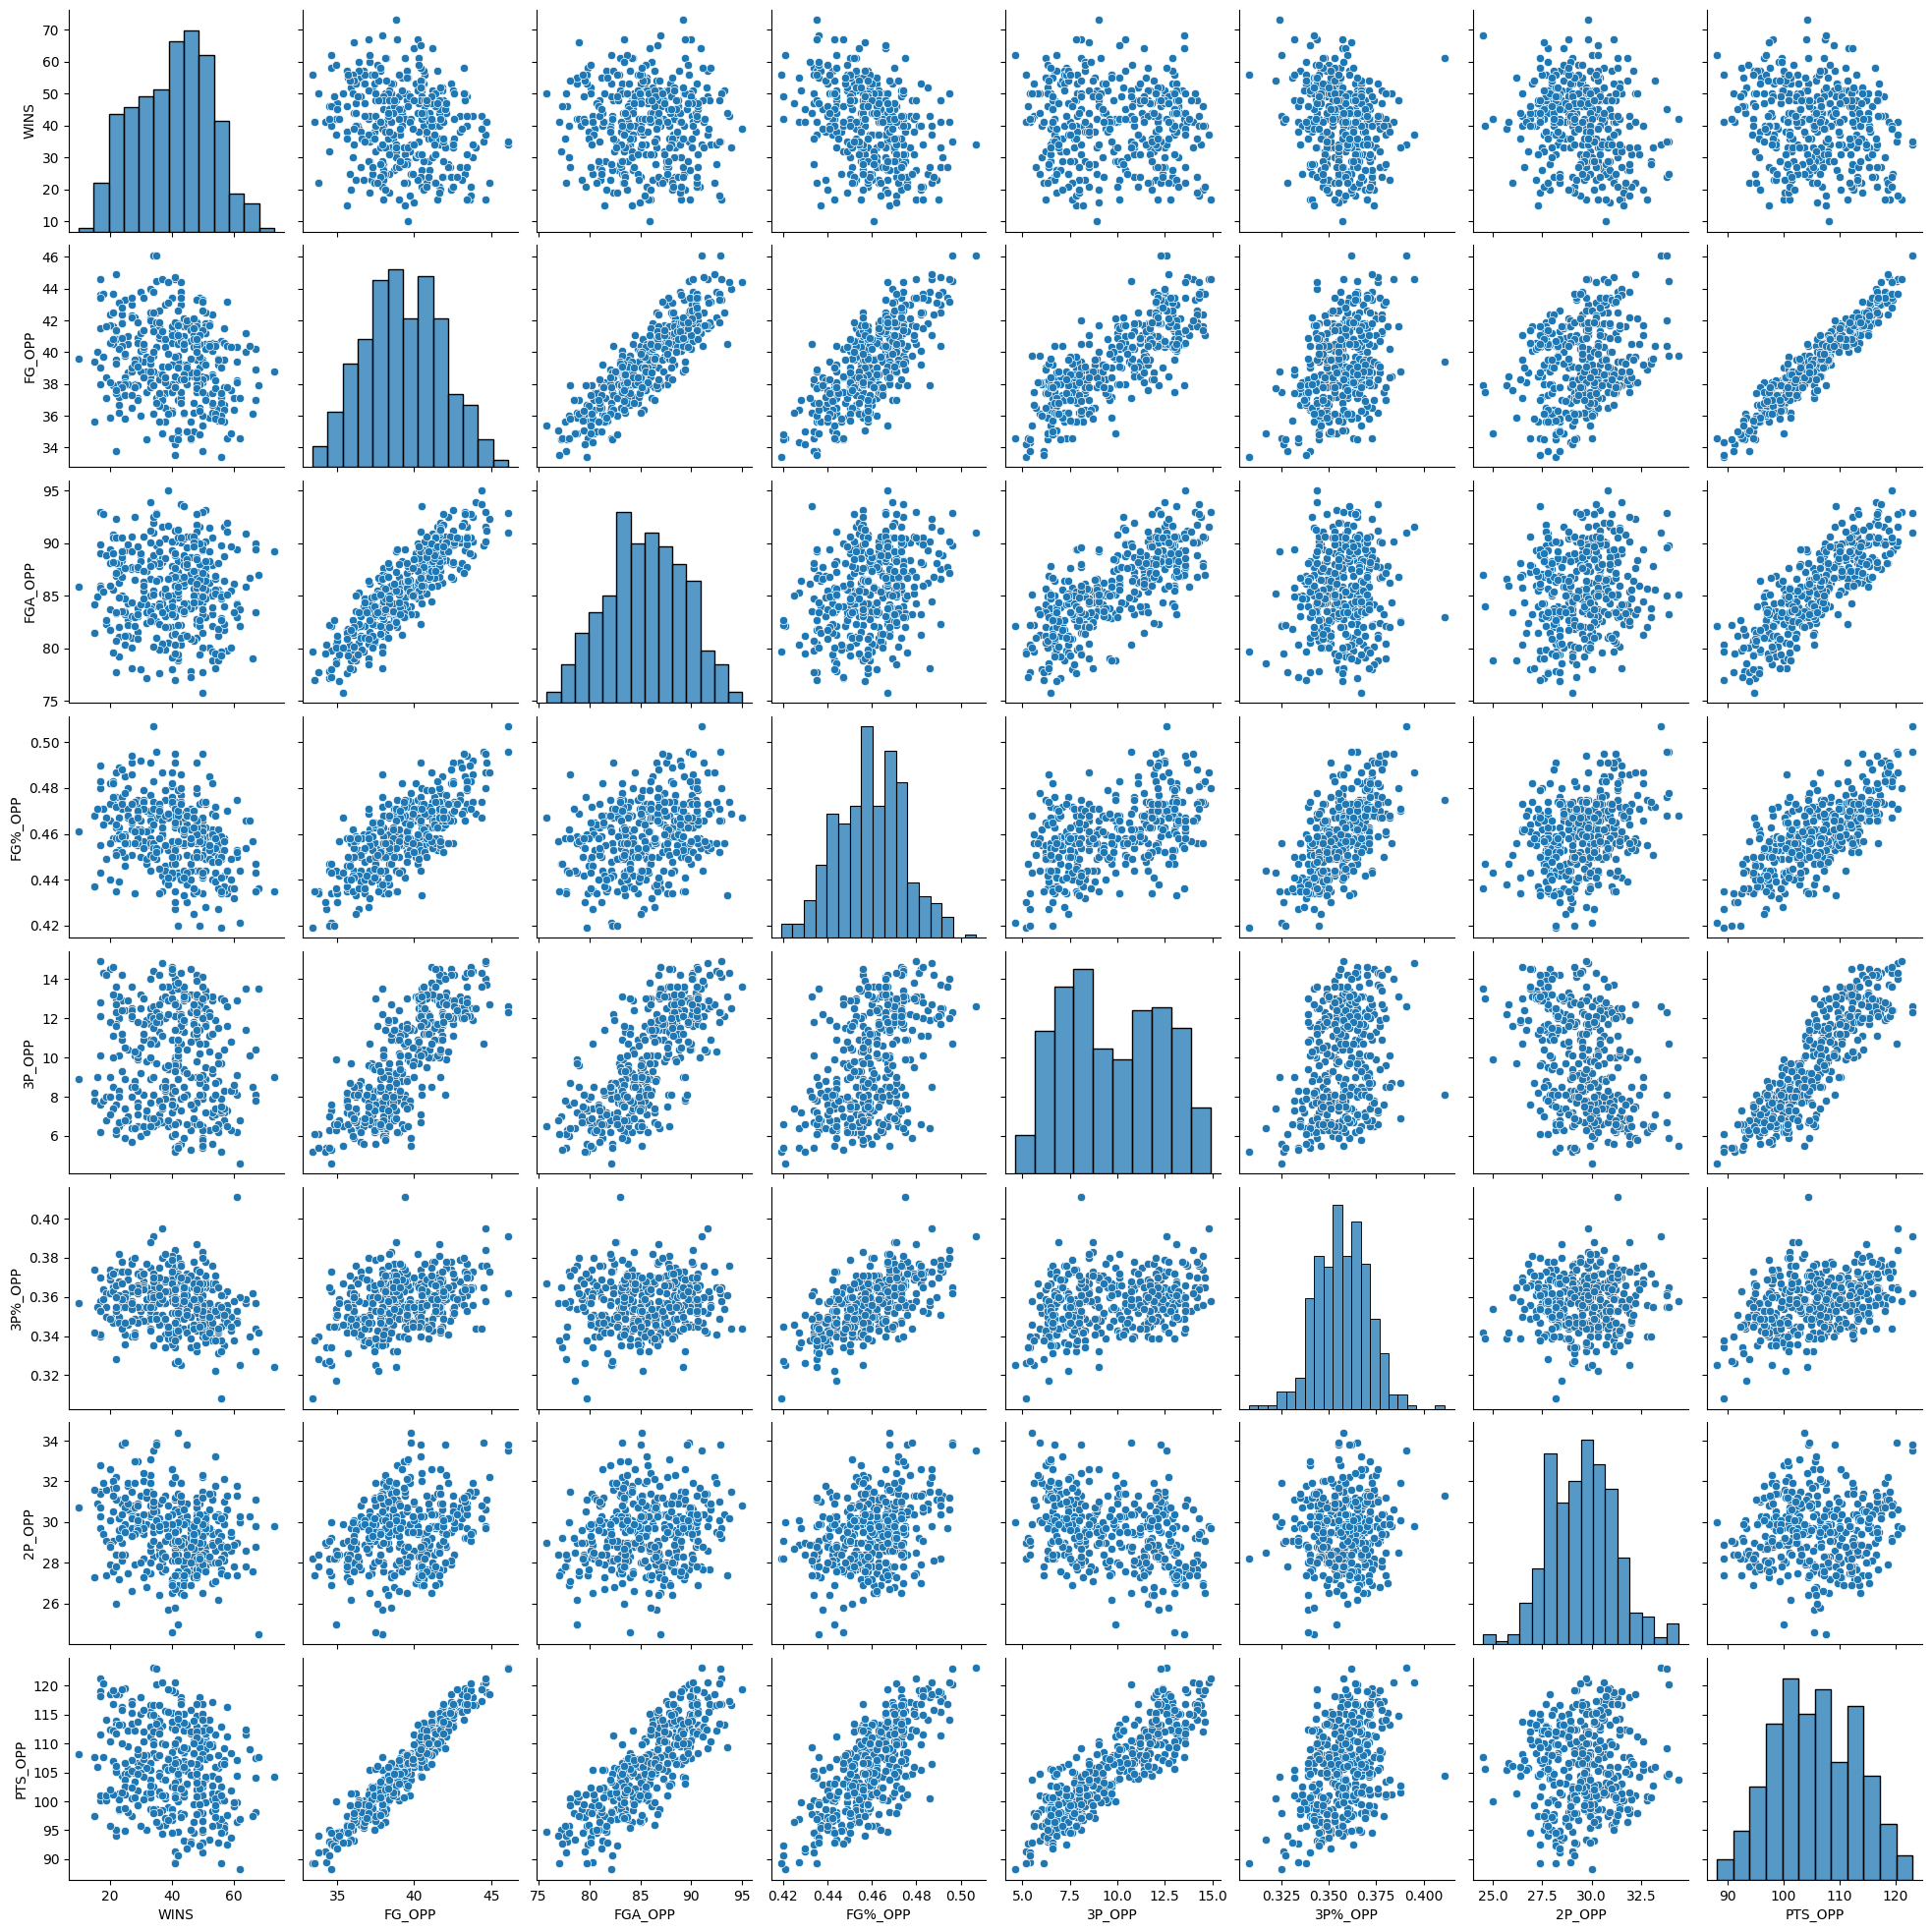

In [7]:
sns.pairplot(merged[shooting_metrics_opp])

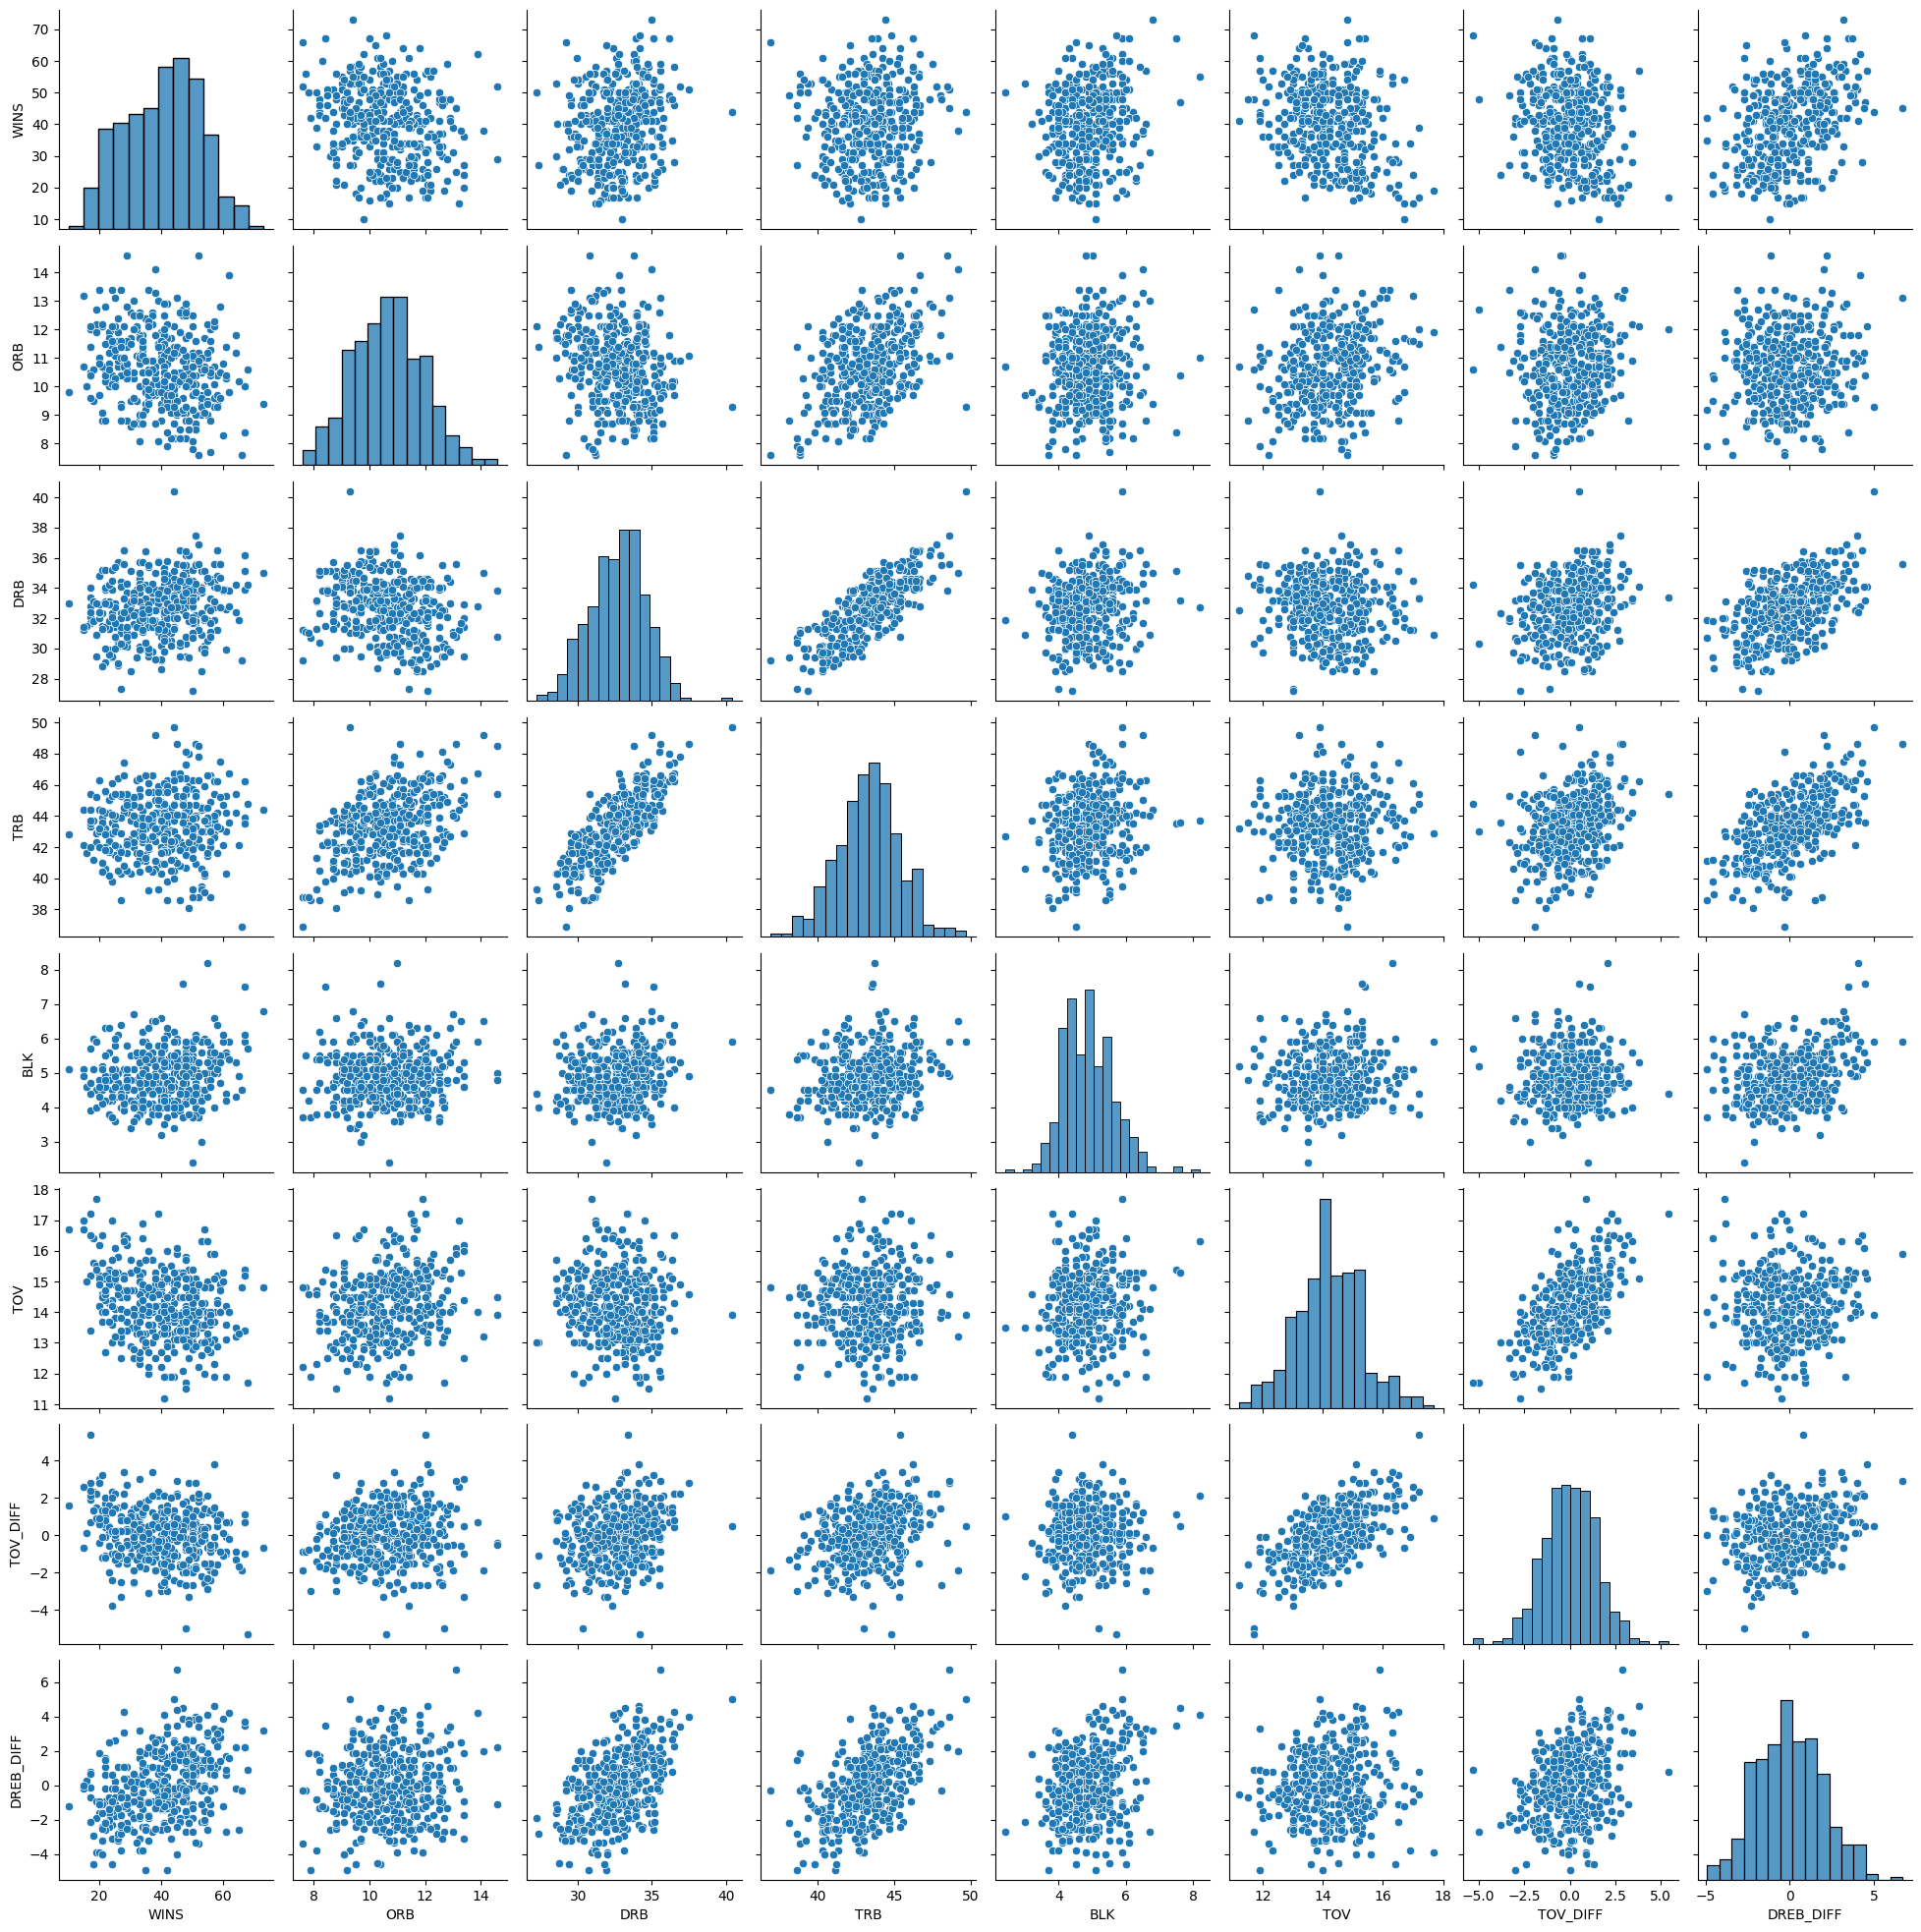

In [10]:
sns.pairplot(merged[other_metrics])

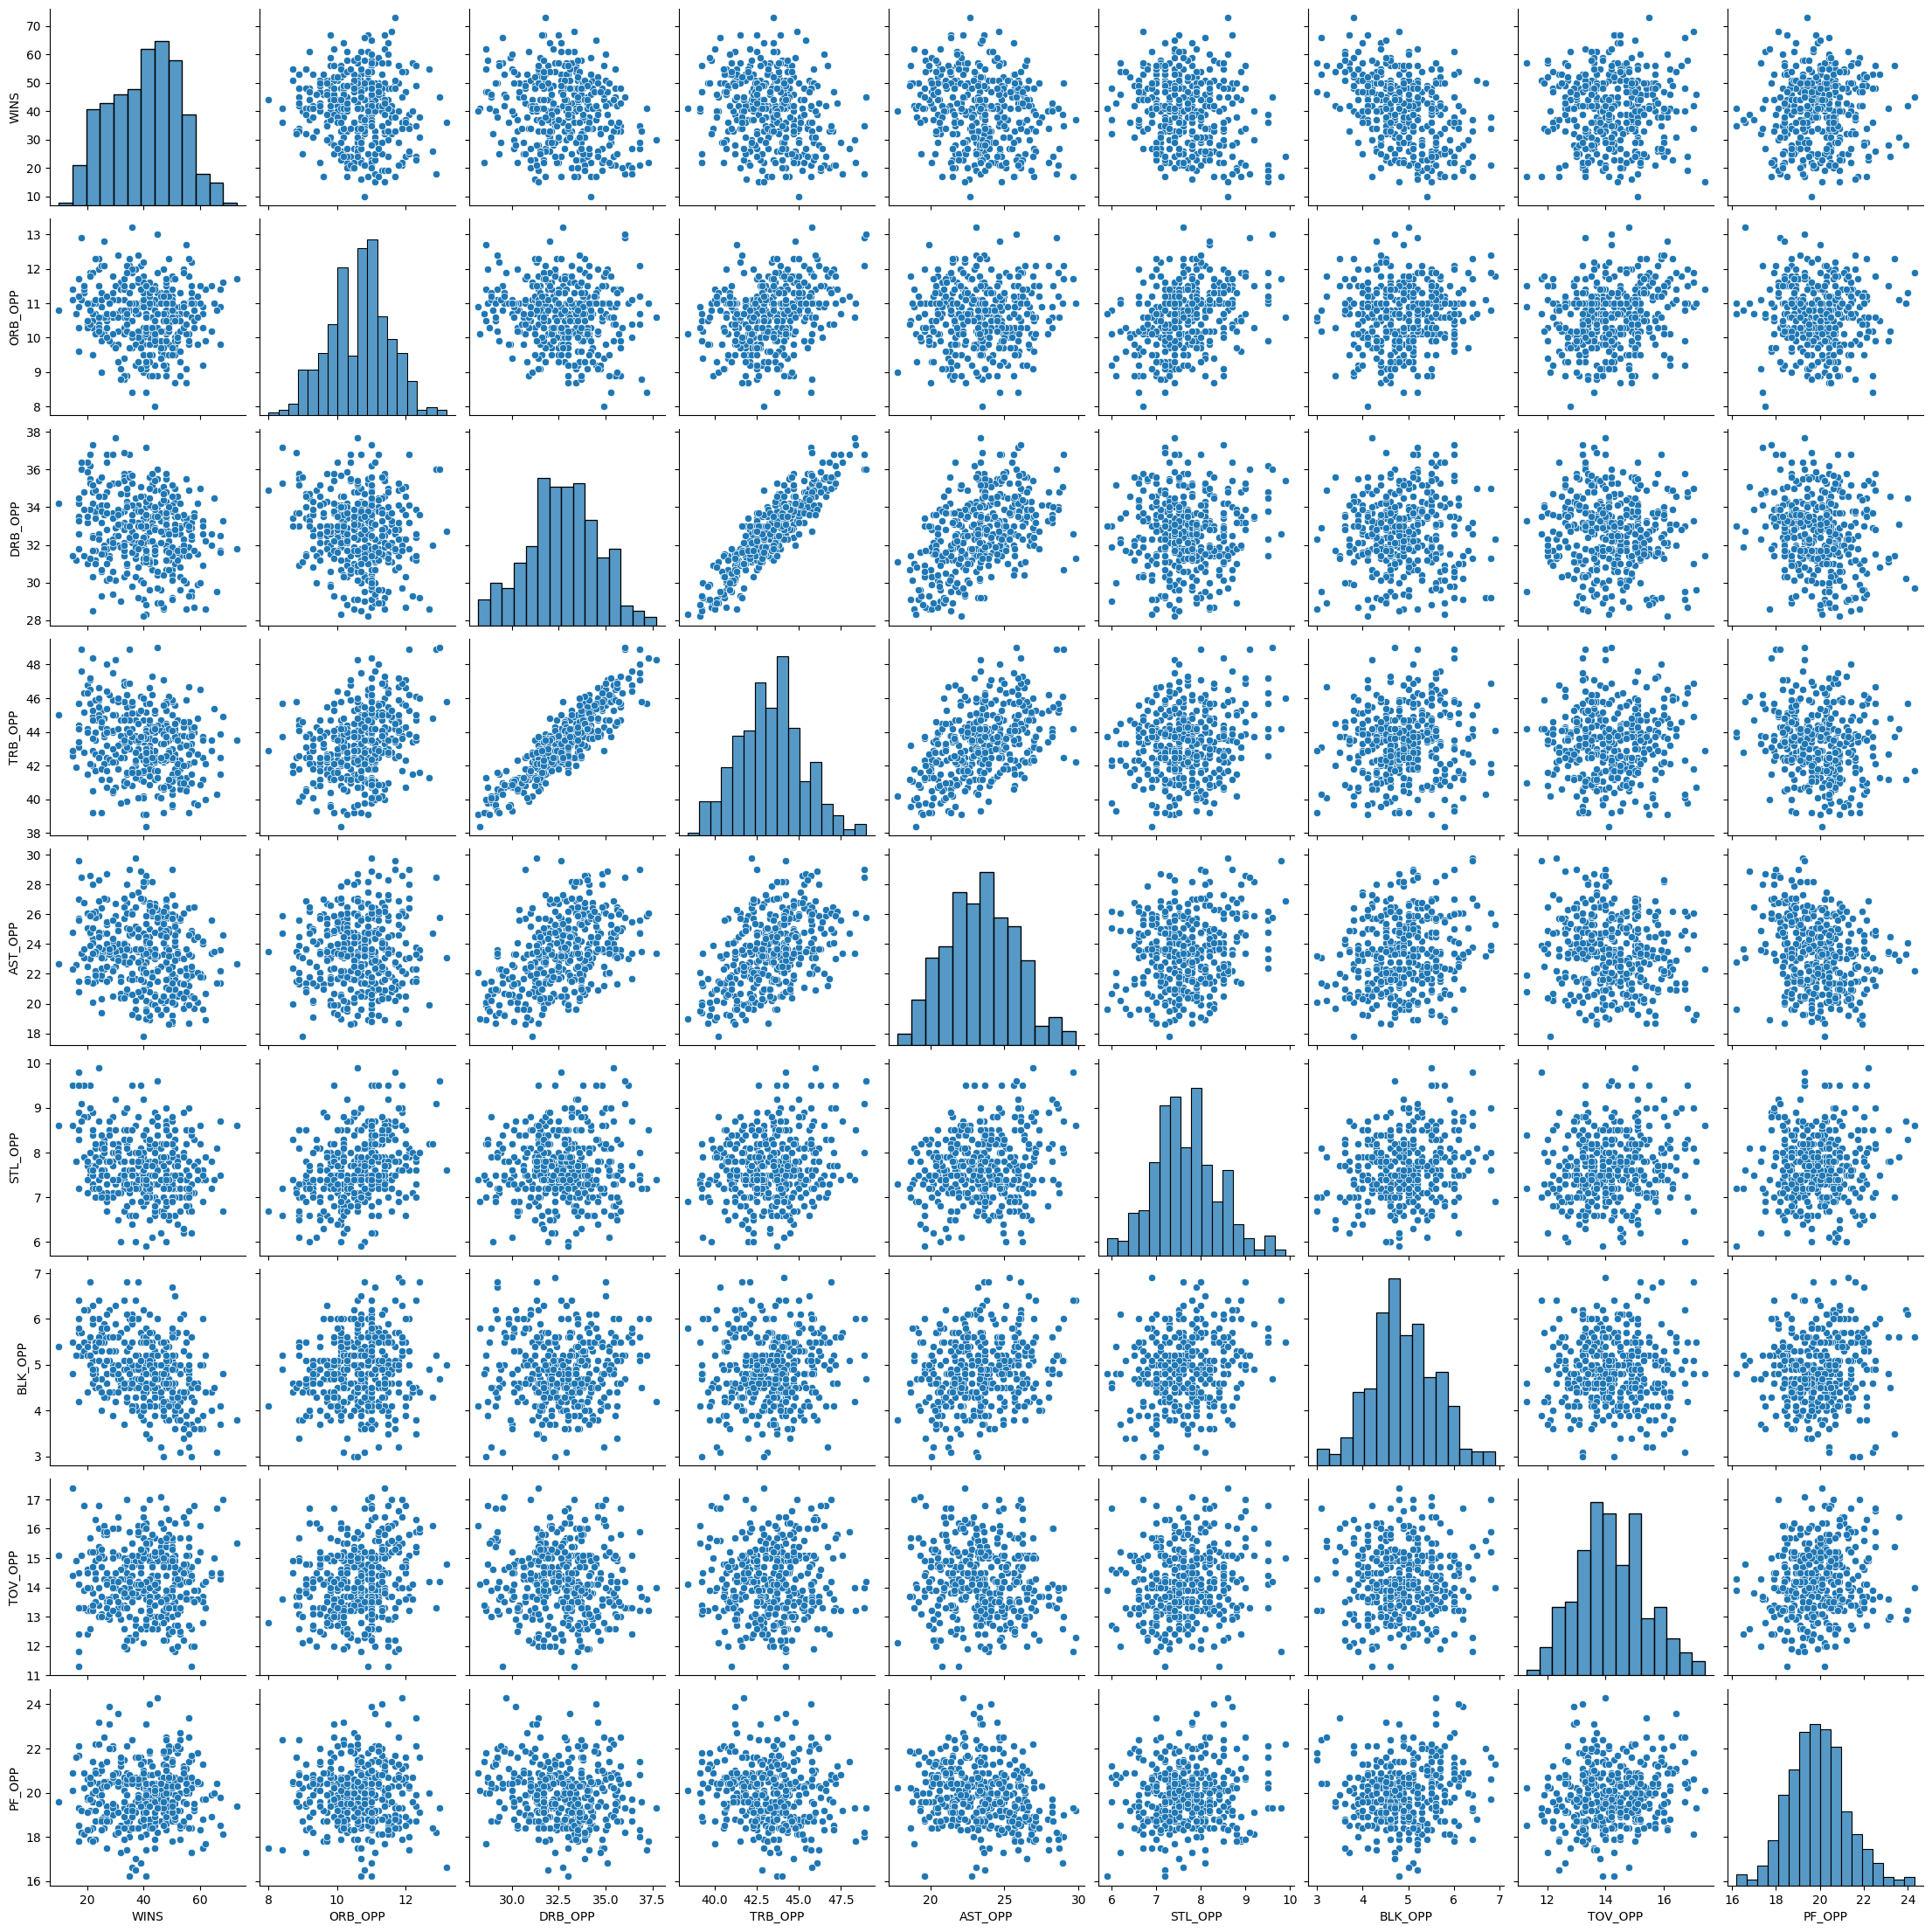

In [11]:
sns.pairplot(merged[other_metrics_opp])

In [78]:
merged.columns

Index(['Rk', 'Team', 'G', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P',
       '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL',
       'BLK', 'TOV', 'PF', 'PTS', 'SEASON', 'Rk_OPP', 'G_OPP', 'MP_OPP',
       'FG_OPP', 'FGA_OPP', 'FG%_OPP', '3P_OPP', '3PA_OPP', '3P%_OPP',
       '2P_OPP', '2PA_OPP', '2P%_OPP', 'FT_OPP', 'FTA_OPP', 'FT%_OPP',
       'ORB_OPP', 'DRB_OPP', 'TRB_OPP', 'AST_OPP', 'STL_OPP', 'BLK_OPP',
       'TOV_OPP', 'PF_OPP', 'PTS_OPP', 'RANK', 'TEAM_ABBREVIATION', 'RECORD',
       'PLAYERS_ACTIVE', 'AVG_AGE_TEAM', 'TOTAL_CAP_ALLOCATIONS',
       'CAP_SPACE_ALL', 'ACTIVE', 'ACTIVE_TOP_3', 'DEAD_CAP', 'TEAM_ID',
       'WINS', 'TOP_3_RATIO', 'CAP_SPACE_RATIO', 'DEAD_CAP_RATIO', 'PTS_DIFF',
       'REB_DIFF', 'TOV_DIFF', 'FG%_DIFF'],
      dtype='object')

In [22]:
regressors = [
    "FG%", "3P%", "FG%_OPP", "PTS_DIFF", "DREB_DIFF", "PREV_WINS",
    "TOP_3_RATIO",
    "CAP_SPACE_RATIO",
    "DEAD_CAP_RATIO",
    "AVG_AGE_TEAM"
]
all_metrics = regressors + ['WINS']

In [23]:
print(len(merged))
df = merged.dropna(subset=all_metrics)
print(len(df))


390
351


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, BayesianRidge, Lasso
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd


data_2024 = df[df['SEASON']==2024] 
data = df[df['SEASON']!=2024]

# --- Define features and target ---
X_train = data[regressors]
y_train = data["WINS"]

X_test = data_2024[regressors]
y_test = data_2024["WINS"]

# --- Standardize features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 1️⃣ Ridge Regression ---
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_train_pred))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))

# --- 2️⃣ Bayesian Ridge Regression ---
bayesian = BayesianRidge()
bayesian.fit(X_train_scaled, y_train)
bayes_train_pred = bayesian.predict(X_train_scaled)
bayes_test_pred = bayesian.predict(X_test_scaled)
bayes_train_rmse = np.sqrt(mean_squared_error(y_train, bayes_train_pred))
bayes_test_rmse = np.sqrt(mean_squared_error(y_test, bayes_test_pred))

# --- 3️⃣ Lasso Regression ---
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)
lasso_train_rmse = np.sqrt(mean_squared_error(y_train, lasso_train_pred))
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_test_pred))

# --- 4️⃣ PCA + Ridge ---
pca = PCA(n_components=min(X_train_scaled.shape[1], 8))
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
ridge_pca = Ridge(alpha=1.0, random_state=42)
ridge_pca.fit(X_train_pca, y_train)
ridge_pca_train_pred = ridge_pca.predict(X_train_pca)
ridge_pca_test_pred = ridge_pca.predict(X_test_pca)
ridge_pca_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_pca_train_pred))
ridge_pca_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_pca_test_pred))

# --- Compare Results ---
print("📊 Model Comparison (RMSE):")
print(f"Ridge        → Train: {ridge_train_rmse:.3f} | Test: {ridge_test_rmse:.3f}")
print(f"Bayesian     → Train: {bayes_train_rmse:.3f} | Test: {bayes_test_rmse:.3f}")
print(f"Lasso        → Train: {lasso_train_rmse:.3f} | Test: {lasso_test_rmse:.3f}")
print(f"PCA + Ridge  → Train: {ridge_pca_train_rmse:.3f} | Test: {ridge_pca_test_rmse:.3f}")


📊 Model Comparison (RMSE):
Ridge        → Train: 7.884 | Test: 7.816
Bayesian     → Train: 7.895 | Test: 8.091
Lasso        → Train: 7.891 | Test: 7.901
PCA + Ridge  → Train: 8.010 | Test: 9.094


In [25]:
data_2024['y_pred'] = ridge_test_pred

data_2024[['Team', 'WINS', 'y_pred']]

/var/folders/2r/lz10gl_11w59r5g2yq153k7r0000gn/T/ipykernel_4060/2352490586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2024['y_pred'] = ridge_test_pred


,Team,WINS,y_pred
124,Atlanta Hawks,40.0,39.896633
127,Boston Celtics,61.0,57.619415
149,Brooklyn Nets,26.0,31.981328
148,Charlotte Hornets,19.0,26.422671
125,Chicago Bulls,39.0,36.943700
120,Cleveland Cavaliers,64.0,53.360737
134,Dallas Mavericks,39.0,41.875412
122,Denver Nuggets,50.0,49.879267
131,Detroit Pistons,44.0,31.920757
136,Golden State Warriors,48.0,48.458439


Top features by absolute importance:


PTS_DIFF           4.313325
PREV_WINS          3.534101
AVG_AGE_TEAM       2.324710
CAP_SPACE_RATIO    1.847301
DEAD_CAP_RATIO     0.416955
FG%                0.407319
DREB_DIFF          0.387495
FG%_OPP            0.287738
3P%                0.101095
TOP_3_RATIO        0.011128
dtype: float64

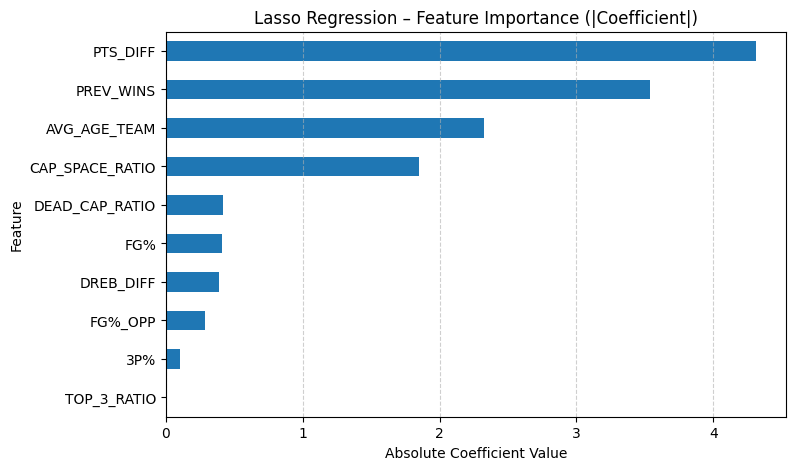

In [ ]:
import matplotlib.pyplot as plt

# --- Extract coefficients ---
coefs = pd.Series(ridge.coef_, index=X_train.columns)
coefs_abs = coefs.abs().sort_values(ascending=False)

# --- Display top features ---
print("Top features by absolute importance:")
display(coefs_abs.head(10))

# --- Plot ---
plt.figure(figsize=(8,5))
coefs_abs.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Ridge Regression – Feature Importance (|Coefficient|)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


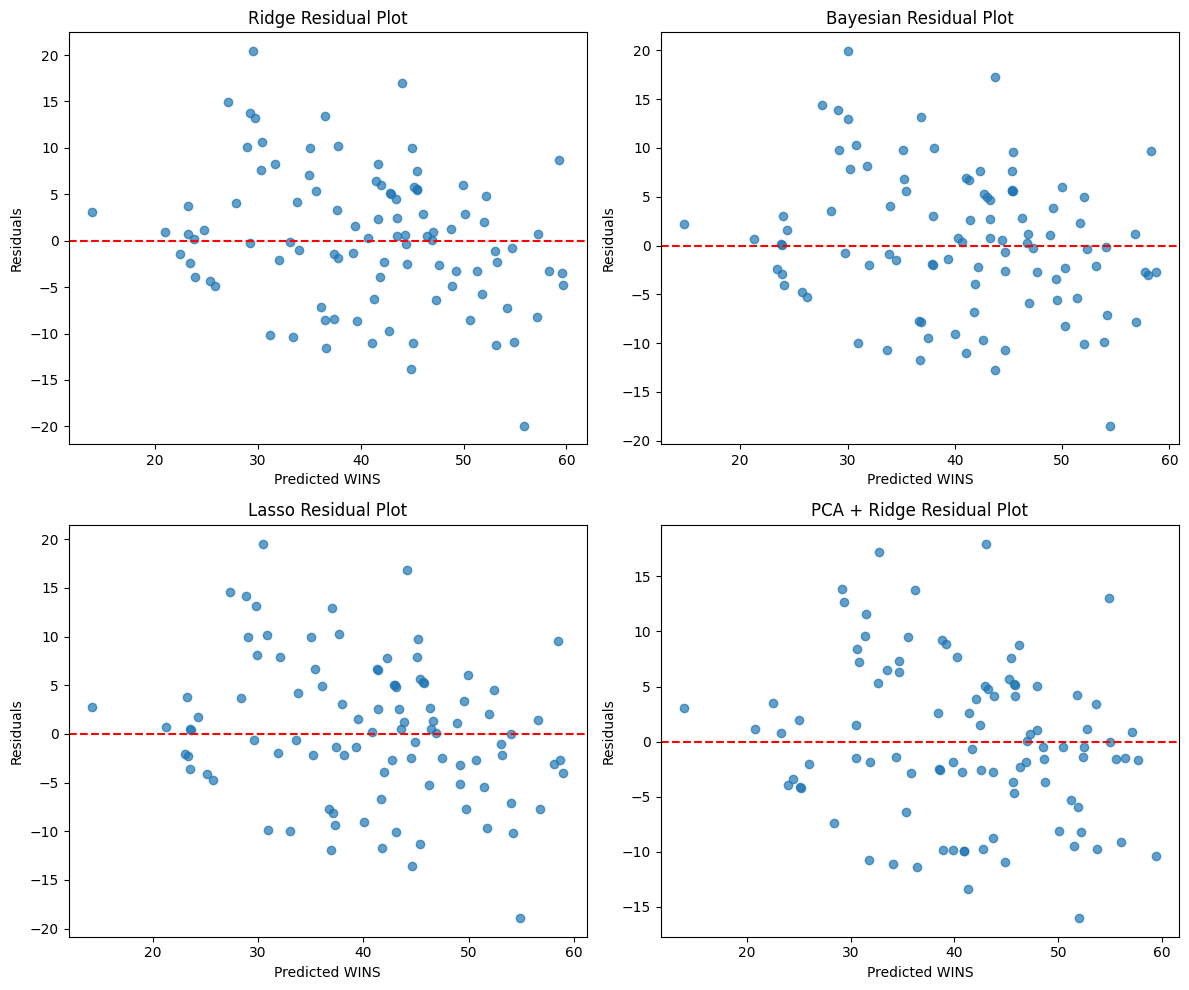

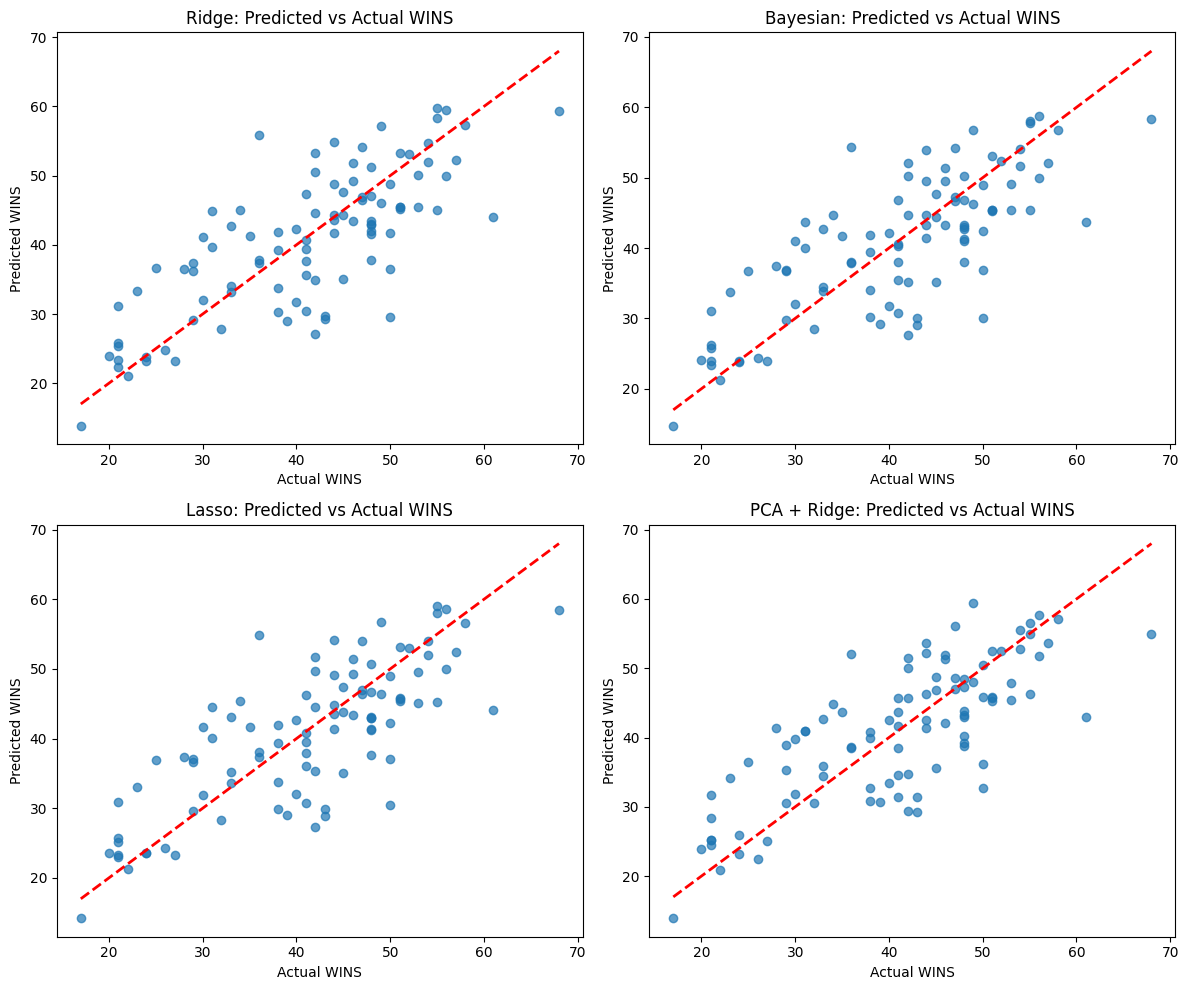

In [27]:
# --- Residual plots ---
models = {
    "Ridge": (ridge_test_pred, y_test),
    "Bayesian": (bayes_test_pred, y_test),
    "Lasso": (lasso_test_pred, y_test),
    "PCA + Ridge": (ridge_pca_test_pred, y_test)
}

plt.figure(figsize=(12, 10))
for i, (name, (y_pred, y_true)) in enumerate(models.items(), 1):
    residuals = y_true - y_pred
    plt.subplot(2, 2, i)
    plt.scatter(y_pred, residuals, alpha=0.7)
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"{name} Residual Plot")
    plt.xlabel("Predicted WINS")
    plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

# --- Predicted vs Actual plots ---
plt.figure(figsize=(12, 10))
for i, (name, (y_pred, y_true)) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i)
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.title(f"{name}: Predicted vs Actual WINS")
    plt.xlabel("Actual WINS")
    plt.ylabel("Predicted WINS")
plt.tight_layout()
plt.show()

In [7]:
merged.columns

Index(['Rk', 'Team', 'G', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P',
       '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL',
       'BLK', 'TOV', 'PF', 'PTS', 'SEASON', 'Rk_OPP', 'G_OPP', 'MP_OPP',
       'FG_OPP', 'FGA_OPP', 'FG%_OPP', '3P_OPP', '3PA_OPP', '3P%_OPP',
       '2P_OPP', '2PA_OPP', '2P%_OPP', 'FT_OPP', 'FTA_OPP', 'FT%_OPP',
       'ORB_OPP', 'DRB_OPP', 'TRB_OPP', 'AST_OPP', 'STL_OPP', 'BLK_OPP',
       'TOV_OPP', 'PF_OPP', 'PTS_OPP', 'RANK', 'TEAM_ABBREVIATION', 'RECORD',
       'PLAYERS_ACTIVE', 'AVG_AGE_TEAM', 'TOTAL_CAP_ALLOCATIONS',
       'CAP_SPACE_ALL', 'ACTIVE', 'ACTIVE_TOP_3', 'DEAD_CAP', 'TEAM_ID',
       'WINS', 'TOP_3_RATIO', 'CAP_SPACE_RATIO', 'DEAD_CAP_RATIO', 'PTS_DIFF',
       'DREB_DIFF', 'TOV_DIFF', 'FT%_DIFF', 'PREV_WINS'],
      dtype='object')

In [29]:
data_2024[data_2024['TEAM_ABBREVIATION'].isin(['MIA', 'SAC', 'MEM'])][['TEAM_ABBREVIATION', 'WINS', 'y_pred']]

,TEAM_ABBREVIATION,WINS,y_pred
121,MEM,48.0,45.810942
143,MIA,37.0,44.177034
129,SAC,40.0,46.174351
